                                                        PHASE 3                                                             

In this ive learnt so many things like optimisers nn.modules and classes 

mse loss = mean squared error

optimiser = its kinda helper which wll change the learning rate by itself according to gradient value or we can say wrt gradient.

backward = too see which value is the reason for wrong prediction.

input -> reset gradient -> predict -> loss -> loss backward -> update w (weight) -> optimiser -> predict again

This works on weight and bias 

value = w.x + b

weight,ur input + bias

In [ ]:
import torch 
import torch.nn as nn
import torch.optim as optim

class mymodel(nn.Module):
    def __init__(self):
        super().__init__()
        self.Linear = nn.Linear(1,1)
    def forward(self,x):
        return self.Linear(x)

x = torch.tensor([[1],[2],[3],[4],[5]])
y = torch.tensor([[2],[4],[6],[8],[10]])

x = x.float()
y = y.float()

model = mymodel()

loss_fn = nn.MSELoss()

optimiser = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(10):
    optimiser.zero_grad()
    #see gradient tells direction ( increase or decrease ) the value to decrease loss!
    y_pred = model(x)
    loss = loss_fn(y_pred,y)
    loss.backward()
    optimiser.step()
    print(f"EPOCH : {epoch + 1}, LOSS : {loss.item():.4f},  PREDICTION : {y_pred}")

print("My first model by myself from scratch! ... ik every single thing abt it!!")

DATASET - set of data we need to train out model.

DATALOADERS - DL takes data from dataset then create batches of it ( we cant feel whole data by one ) and also shuffles data and feed to out model.

dataset - 1 sample.
dataloader - group into batches.
model - learn by batches .

Using device: cpu
Epoch : 1/5 | Loss : 324.97
Epoch : 2/5 | Loss : 131.39
Epoch : 3/5 | Loss : 90.27
Epoch : 4/5 | Loss : 68.35
Epoch : 5/5 | Loss : 52.26
Total Accuracy : 97.33
Model saved - MNIST model.pth


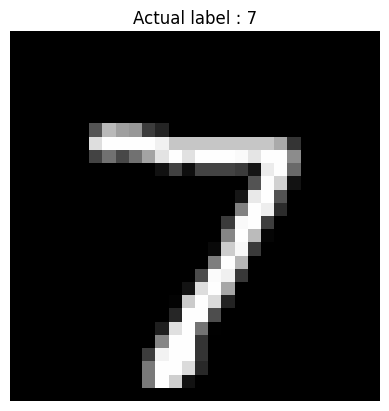

User picked image index : 0
Predicted label : 7
Actual value : 7


In [ ]:
#DATA → LOADER → MODEL → TRAIN → TEST → PREDICT

import torch
import torch.nn as nn 
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:",device)
transform = transforms.ToTensor()

train_data = MNIST(
    root = "data",
    train = True,
    download = True,
    transform = transform)

test_data = MNIST(
    root = "data",
    train = False,
    download = True,
    transform = transform)

train_loader = DataLoader(train_data,
        batch_size = 64,
        shuffle = True)

test_loader = DataLoader(test_data,
        batch_size = 64,
        shuffle = True)

class mymodel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            #Layers
            nn.Linear(28*28, 128),
            nn.ReLU(),
            
            nn.Linear(128,64),
            nn.ReLU(),
            
            nn.Linear(64, 10)
        )
    def forward(self,x):
        return self.net(x)

model = mymodel().to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs,labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    print(f"Epoch : {epoch + 1}/{epochs} | Loss : {total_loss:.2f}")

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, lables in test_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        predictions = outputs.argmax(dim=1)
        
        correct += (predictions == lables).sum().item()
        total += lables.size(0)
        
accuracy = 100 * correct/total
print(f"Total Accuracy : {accuracy:.2f}")

torch.save(model.state_dict(), "MNIST model.pth")
print("Model saved - MNIST model.pth")

index = 0
image, true_label = test_data[index]

plt.imshow(image.squeeze(), cmap = "gray")
plt.title(f"Actual label : {true_label}")
plt.axis("off")
plt.show()

image_flat = image.view(1, -1).to(device)

with torch.no_grad():
    output = model(image_flat)
    predicted_label = output.argmax(dim=1).item()
    
print("User picked image index :",index)
print("Predicted label :",predicted_label)
print("Actual value :",true_label)

In [ ]:
# 1. Initialize the model structure
loaded_model = mymodel() 

# 2. Load the saved weights (state_dict)
# 'MNIST model.pth' is the filename you used earlier
state_dict = torch.load("MNIST model.pth")

# 3. Apply weights to the model
loaded_model.load_state_dict(state_dict)

# 4. Move to device (GPU/CPU) and set to evaluation mode
loaded_model.to(device)
loaded_model.eval()

# Assuming 'input_image' is a single MNIST image tensor
# Flatten it if your model expects a 1D vector (like your Linear model)
input_data = input_image.view(1, -1).to(device)

with torch.no_grad():
    prediction_logits = loaded_model(input_data)
    predicted_class = prediction_logits.argmax(dim=1).item()

print(f"The model thinks this is a: {predicted_class}")